## Current Population Survey Data Practice
Gavin Qu, 01/02/2026

### Day 0 - Gain Familiarity

In [88]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/nov25pub.csv")

In [89]:
print(f"Shape of the DataFrame: {df.shape}\n")
print(df.info())
print(df.dtypes.value_counts())

Shape of the DataFrame: (121723, 394)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121723 entries, 0 to 121722
Columns: 394 entries, hrhhid2 to syngeo
dtypes: float64(347), int64(47)
memory usage: 365.9 MB
None
float64    347
int64       47
Name: count, dtype: int64


**Drill B — Column Taxonomy**
* Create four Python lists of column names:
    1. Demographics (age, sex, race, marital status)
    2. Labor market outcomes (wages, hours, employment status)
    3. Geography (state, metro, region)
    4. Survey/meta variables (weights, IDs, flags)

- Demographics,"PRTAGE (Age), PESEX (Sex), PTDTRACE (Race), PEMARITL (Marital Status), PEEDUCA (Education), PEHSPNON (Hispanic/Non-Hispanic)"
- Labor Market,"PEMLR (Labor Force Status), PEHRUSLT (Hours worked/first job + second), PTERNHLY (Hourly Wage), PTERNWA (weekly wage), PEERNWKP (weeks worked)
- Geography,"GEREG (Region), GESTFIPS (State), GTCBSASZ (Metro Size), GTMETSTA (Metropolitan Status)"
- Meta,"PWSSWGT (Final Weight), PWFMWGT (Family Weight), HRHHID (Household ID part 1), HRHHID2 (household part 2), PULINENO: The person’s line number", PRTFAGE (top code flag)

In [90]:
df.columns = [col.upper() for col in df.columns] # make df cols all uppercase

demographics = ['PRTAGE', 'PESEX', 'PTDTRACE', 'PEMARITL', 'PEEDUCA','PEHSPNON']
labor_market = ['PEMLR', 'PEHRUSLT', 'PTERNHLY', 'PTERNWA', 'PEERNWKP']
geography = ['GEREG', 'GESTFIPS', 'GTCBSASZ', 'GTMETSTA']
meta_vars = ['PWSSWGT', 'PWFMWGT', 'HRHHID', 'HRHHID2', 'PULINENO', 'PRTFAGE']

columns_of_interest = demographics + labor_market + geography + meta_vars
filtered_df = df[columns_of_interest].copy()

In [91]:
filtered_df.head()

,PRTAGE,PESEX,PTDTRACE,PEMARITL,PEEDUCA,PEHSPNON,PEMLR,PEHRUSLT,PTERNHLY,PTERNWA,...,GEREG,GESTFIPS,GTCBSASZ,GTMETSTA,PWSSWGT,PWFMWGT,HRHHID,HRHHID2,PULINENO,PRTFAGE
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3,1,0,2,NaN,NaN,580000770091211,19011,NaN,0
1,85.0,2.0,1.0,3.0,43.0,2.0,5.0,-1.0,-1.0,-1.0,...,3,1,0,2,26361458.0,26361458.0,72908050701101,19011,1.0,1
2,73.0,1.0,1.0,6.0,46.0,2.0,5.0,-1.0,-1.0,-1.0,...,3,1,2,1,31928007.0,31928007.0,100909018705680,19011,1.0,0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3,1,3,1,NaN,NaN,140140752081111,19011,NaN,0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3,1,3,1,NaN,NaN,51824410701111,19011,NaN,0


**Drill C — Missingness & Coding Patterns**
1. Compute missingness rate for all columns.
2. Identify:
    * columns with >90% missing
    * columns with exactly 0 missing
3. For three columns, inspect unique values:
    * df[col].value_counts(dropna=False).head(10)


In [92]:
# 1. compute missingness rate
missing_mask = filtered_df.isna() | (filtered_df < 0)
missing_rate = missing_mask.mean().sort_values(ascending=False)
print(f"Top missing rate: {missing_rate.head()}")

Top missing rate: PEERNWKP    0.978237
PTERNHLY    0.954865
PTERNWA     0.919810
PEHRUSLT    0.667811
PEMLR       0.378170
dtype: float64


In [93]:
# 2. identify extremes
high_missing = missing_rate[missing_rate > 0.9].index.tolist()
low_missing = missing_rate[missing_rate == 0].index.tolist()
print(f"Columns with > 90% missing: {high_missing}")
print(f"Columns with 0 missing: {low_missing}")

Columns with > 90% missing: ['PEERNWKP', 'PTERNHLY', 'PTERNWA']
Columns with 0 missing: ['GEREG', 'GESTFIPS', 'GTCBSASZ', 'GTMETSTA', 'HRHHID', 'HRHHID2', 'PRTFAGE']


In [94]:
# 3. Inspect unique values
cols_to_inspect = ['PEEDUCA', 'PEMLR', 'PWSSWGT'] # education, labor status, final weight

for col in cols_to_inspect:
    print(f"\n Top 10 value count for {col} (including missing)")
    print(filtered_df[col].value_counts(dropna=False).head(10))


 Top 10 value count for PEEDUCA (including missing)
PEEDUCA
 NaN     31424
 39.0    21006
 43.0    16526
-1.0     14332
 40.0    11453
 44.0     7469
 42.0     4338
 41.0     3471
 37.0     2041
 36.0     1905
Name: count, dtype: int64

 Top 10 value count for PEMLR (including missing)
PEMLR
 1.0    41805
 NaN    31424
 5.0    17972
-1.0    14608
 7.0     9352
 6.0     3579
 4.0     1542
 2.0     1209
 3.0      232
Name: count, dtype: int64

 Top 10 value count for PWSSWGT (including missing)
PWSSWGT
NaN           31424
0.0             276
38313797.0       15
3624130.0        15
36369640.0       14
36602024.0       14
40686060.0       13
8874491.0        12
31394569.0       12
40333400.0       12
Name: count, dtype: int64


### Day 1
**Task A:**
Create a renaming dictionary that maps CPS codes → readable names

- Demographics,"PRTAGE (Age), PESEX (Sex), PTDTRACE (Race), PEMARITL (Marital Status), PEEDUCA (Education), PEHSPNON (Hispanic/Non-Hispanic)"
- Labor Market,"PEMLR (Labor Force Status), PEHRUSLT (Hours worked/first job + second), PTERNHLY (Hourly Wage), PTERNWA (weekly wage), PEERNWKP (weeks worked)
- Geography,"GEREG (Region), GESTFIPS (State), GTCBSASZ (Metro Size), GTMETSTA (Metropolitan Status)"
- Meta,"PWSSWGT (Final Weight), PWFMWGT (Family Weight), HRHHID (Household ID part 1), HRHHID2 (household part 2), PULINENO: The person’s line number", PRTFAGE (top code flag)

In [95]:
cps_dict = {
    "PRTAGE": "age", "PESEX": "sex", "PTDTRACE": "race", "PEMARITL": "marital_status", "PEEDUCA": "education", "PEHSPNON": "hispanic", 
    "PEMLR":"lfs", "PEHRUSLT": "hours_usual", "PTERNHLY": "wage_hourly", "PTERNWA": "wage_weekly", "PEERNWKP": "weeks_worked", 
    "GEREG": "region", "GESTFIPS": "state", "GTCBSASZ": "metro_size", "GTMETSTA": "metro_status", "PWSSWGT": "wt_person",
    "PWFMWGT": "wt_family", "HRHHID": "hhid1", "HRHHID2": "hhid2", "PULINENO": "line_no", "PRTFAGE": "topcode_age_flag"
}

df1 = filtered_df.rename(columns=cps_dict)

In [96]:
# construct household id
for col in ['hhid1', 'hhid2', 'line_no']: 
    df1[col] = df1[col].fillna(0).astype(int).astype(str)   # avoid 1.0 in case loaded as floats 

df1['hhid'] = df1['hhid1'] + "-" + df1['hhid2']

df1['person_id'] = df1['hhid'] + "-" + df1['line_no'].str.zfill(2) # padding up to 2 digits

1. Uniqueness and NaN check 3-block audit function
2. The Repeatable Pattern: pd.crosstab(df['Categorical_A'], df['Categorical_B'])
3. End your coding tasks with Assertions. 
```
assert df['person_id'].is_unique, "Critical Error: Duplicates in ID"
assert (df['PRTAGE'] >= 0).all(), "Warning: Negative ages detected"
```

In [97]:
# uniqueness and na check
def audit(df, col_name):
    print(f"--- Audit {col_name} Column ---")
    print(f"Missing NaN Check: {df[col_name].isna().sum()}")
    print(f"Missing CPS -1: {(df[col_name] < 0).sum()}")    # check for sentinel values -1, -2
    print(f"Unique Values: {df[col_name].nunique()}")
    print(f"Is column unique? {df[col_name].is_unique}")

In [98]:
audit(df1, 'education')
assert df1['person_id'].is_unique, "Error: Duplicates in ID"
# assert (df1['age'] >= 0).all(), "warning: negative ages detected"

--- Audit education Column ---
Missing NaN Check: 31424
Missing CPS -1: 14332
Unique Values: 17
Is column unique? False


In [99]:
df1['person_id'].isna().sum()

np.int64(0)

## Sunday January 11th 2026
### 1. Data Integrity
* Identify missing values in the wage or income column. 
* Choose an imputation or removal strategy and justify it based on the data distribution.

In [100]:
import pandas as pd
import numpy as np

print(df1.columns)

Index(['age', 'sex', 'race', 'marital_status', 'education', 'hispanic', 'lfs',
       'hours_usual', 'wage_hourly', 'wage_weekly', 'weeks_worked', 'region',
       'state', 'metro_size', 'metro_status', 'wt_person', 'wt_family',
       'hhid1', 'hhid2', 'line_no', 'topcode_age_flag', 'hhid', 'person_id'],
      dtype='object')


In [109]:
df1.to_csv("../data/clean_nov25pub.csv", index=False)

In [101]:
# identify missing values in wage
cols = ['wage_hourly', 'wage_weekly'] # mask below will return 2D array of bools
na_mask = (df1[cols].isna() | df1[cols] < 0).any(axis=1) 
result = df1.loc[na_mask, :]
print(f"Shape of Missing Values: {result.shape}")

Shape of Missing Values: (0, 23)


In regard to imputation, first I need to find the distribution of the wage date. This will reveal the wage data's skewness, volume of the missing data, even the missing's correlation with other covariates. Common inputation methods are: 
```
df.filla()
df[].fillna(df[].mean())
df.ffill()
df.interpolate
```
Let's visualize that first using matplotlib's histogram, boxplot, violin plot or the kernel density plot functions

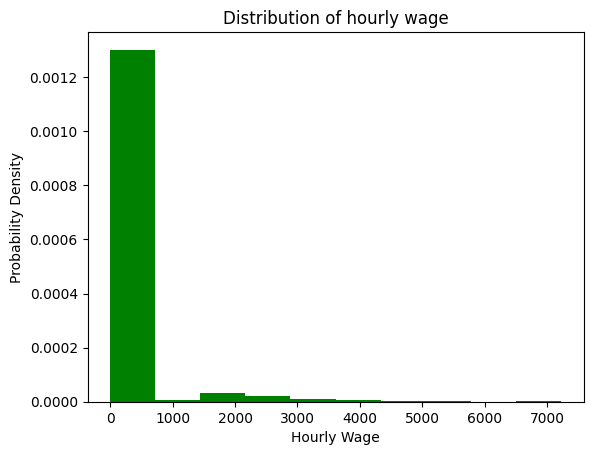

In [102]:
import matplotlib.pyplot as plt

plt.hist(df1['wage_hourly'], bins=10, density=True, color='green')
plt.title("Distribution of hourly wage")
plt.xlabel("Hourly Wage")
plt.ylabel("Probability Density")
plt.show()

Realistically, a wage of 0 probably implies unemployment. I want to check the 'lfs' column to see if the values matches up with unemployment since the data dictionary is unclear about this. 1-2: employed, 3-4 unemployed, 5-7 not in lf. Also, when we run regression later on taking log(wage), this would create problems since log(0) is undefined. 

In [103]:
# contingency table of freq of lfs category and where wage == 0
pd.crosstab(index=(df1['wage_hourly'] == 0), columns=df1['lfs'])

lfs,-1.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0
wage_hourly,,,,,,,,
False,14608,41804,1209,232,1542,17972,3579,9352
True,0,1,0,0,0,0,0,0


### 2. Aggregation
* Calculate the average hourly wage grouped by both state and education_level.
* However, to ensure the results are robust, your final output should only include groups that have at least 50 observations.
* transform() is for broadcasting values, e.g. new column, filter() works better with groupby()

In [104]:
# filter df to only include education
state_edu_stat = df1.groupby(['state', 'education'])['wage_hourly'].agg(['mean','count'])
grouped_stat = state_edu_stat[state_edu_stat['count'] > 50]
grouped_stat

mean  count
state education                   
1     -1.0        -1.000000    225
       37.0       91.365385     52
       39.0      152.139759    415
       40.0      223.468182    220
       41.0      251.108108     74
...                     ...    ...
56     39.0      203.537994    329
       40.0      186.168317    202
       42.0      189.108434     83
       43.0      259.050505    198
       44.0      135.893204    103

[372 rows x 2 columns]

### 3. Visualization
* Generate a visualization that compares the wage distributions of "College Graduates" vs. "Non-Graduates." 
* 31-38: k-12, 39: GED, 40: college no degree, 41: aa, 43: ba, 44, master's, 45: professional, 46: phd
* Create a single plot showing the density of wage_hourly for "Bachelors" and "High School" graduates.

In [105]:
# filter df1 to get wage data for just two subsets
ged_mask = df1['education'] == 39
college_mask = df1['education'] == 43
ged_wage = df1.loc[ged_mask, 'wage_hourly']
college_wage = df1.loc[college_mask, 'wage_hourly']

# log for wage due to skewness
log_ged_wage = np.log10(ged_wage)
log_college_wage = np.log10(college_wage)

/Users/gavinqu/dev/predoc/venv/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/gavinqu/dev/predoc/venv/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


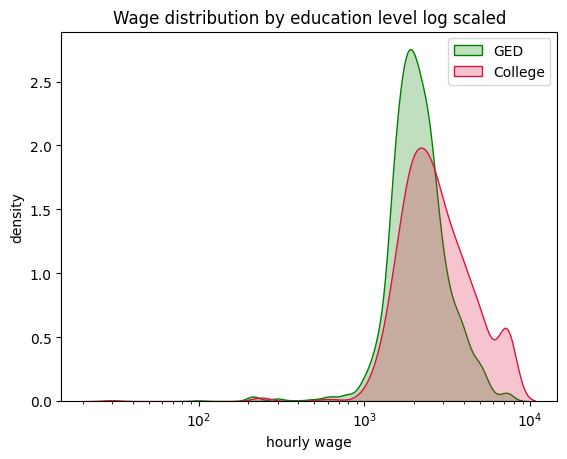

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

clean_ged = ged_wage[ged_wage > 0] # log scale breaks when val < 0 

sns.kdeplot(data=clean_ged, label='GED', color='green', fill=True, log_scale=True) # default is log10
sns.kdeplot(data=college_wage, color='crimson', label='College', fill=True, log_scale=True)

plt.title("Wage distribution by education level log scaled")
plt.xlabel("hourly wage")
plt.ylabel("density")
plt.legend()
plt.show()

we notice the "hump" of college grad wage is to the right of the GED. Now the question should be whether the difference is statistically significant. 

### 4. Inference
* Fit a linear regression model predicting log(wage). 
* Use statsmodels to determine if the interaction between age and education is statistically significant.

In [107]:
import statsmodels.api as sm

mask = (df1['wage_hourly'] > 0) & (df1['education'].isin([39, 43]))
clean_df = df1.loc[mask].copy()

clean_df['is_college'] = np.where(clean_df['education'] == 43, 1, 0)
clean_df['log_wage'] = np.log(clean_df['wage_hourly'])

X = clean_df['is_college']
y = clean_df['log_wage']

# statmodel does not include intercept need to add one
X = sm.add_constant(X)

model = sm.OLS(y, X)
result = model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:               log_wage   R-squared:                       0.063
Model:                            OLS   Adj. R-squared:                  0.063
Method:                 Least Squares   F-statistic:                     196.5
Date:                Sat, 17 Jan 2026   Prob (F-statistic):           2.93e-43
Time:                        15:30:10   Log-Likelihood:                -1809.2
No. Observations:                2927   AIC:                             3622.
Df Residuals:                    2925   BIC:                             3634.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.6470      0.010    748.604      0.0

In [8]:
import time

def multiple(a, b): 
    start_time = time.perf_counter()
    product = 0
    for i in range(a): 
        product += b

    end_time = time.perf_counter()
    duration = end_time - start_time

    return product, duration

multiple(1000000000, 1000000000)

(1000000000000000000, 34.8256012920001)

In [10]:
%%timeit

import numpy as np

def multiple_np(a, b):
    return np.multiply(a, b)

multiple_np(1000000000, 1000000000)

1.09 μs ± 11.5 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
